In [1]:
print("Suraj")

Suraj


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_excel(r"C:\MLOPs_Machine_Learning_Projects\Customer_Churn_Prediction_MLOps_Pipeline\notebook\Telco_customer_churn.xlsx")


In [4]:
df.head(2)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved


In [5]:
df.shape

(7043, 33)

# Data Cleaning

In [6]:
##these are the features with nan value
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

Churn Reason 73.46301 % missing values


In [7]:
features_with_na

['Churn Reason']

# Other Data Cleaning steps

In [8]:
df.duplicated().sum()

np.int64(0)

In [17]:
drop_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Gender",
    "Senior Citizen",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Streaming TV",
    "Streaming Movies",
    "Paperless Billing",
    "Payment Method",
    "Total Charges",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

In [18]:
df = df.drop(columns=drop_cols)

In [19]:
print(df.columns.tolist())

['Partner', 'Tenure Months', 'Internet Service', 'Tech Support', 'Contract', 'Monthly Charges', 'Churn Label']


In [23]:
df.isnull().sum()

Partner             0
Tenure Months       0
Internet Service    0
Tech Support        0
Contract            0
Monthly Charges     0
Churn Label         0
dtype: int64

In [ ]:

df.describe()

,Tenure Months,Monthly Charges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


# Type of Features

In [24]:
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))

Num of Numerical Features : 2


In [25]:
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('Num of Categorical Features :', len(cat_features))

Num of Categorical Features : 5


### Discrete features(discontinuous and have definite feature boundaries)

In [26]:
discrete_features=[feature for feature in num_features if len(df[feature].unique())<=25]
print('Num of Discrete Features :',len(discrete_features))

Num of Discrete Features : 0


### Continues Features ( models where learn sequentially from continuous data streams, updating knowledge without forgetting previous tasks)

In [27]:
continuous_features=[feature for feature in num_features if feature not in discrete_features]
print('Num of Continuous Features :',len(continuous_features))

Num of Continuous Features : 2


# Split X and Y

Split Dataframe to X and y

Here we set a variable X i.e, independent columns, and a variable y i.e, dependent column as the “Case_Status” column.

Train_Test_Split se pahle sare cols X and y me define krna hota hai

In [28]:
df.head(2)

,Partner,Tenure Months,Internet Service,Tech Support,Contract,Monthly Charges,Churn Label
0,No,2,DSL,No,Month-to-month,53.85,Yes
1,No,2,Fiber optic,No,Month-to-month,70.70,Yes


In [29]:
X = df.drop('Churn Label', axis=1) # Target cols ko chhod ke sare cols. 
y = df['Churn Label'].map({'Yes': 1, 'No': 0}).astype(int) # Only target cols ko liya 

In [30]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: Churn Label, dtype: int64

Yaha target cols ka output categorical me hai so esko numerical me convert krna hai .

Manual encoding target column

In [31]:
# If the target column has Denied it is encoded as 1 others as 0
# Yes = 1
# No= 0
y = df['Churn Label'].map({'Yes': 1, 'No': 0}).astype(int)

# Feature Transformation

### Numerical Features Distribution

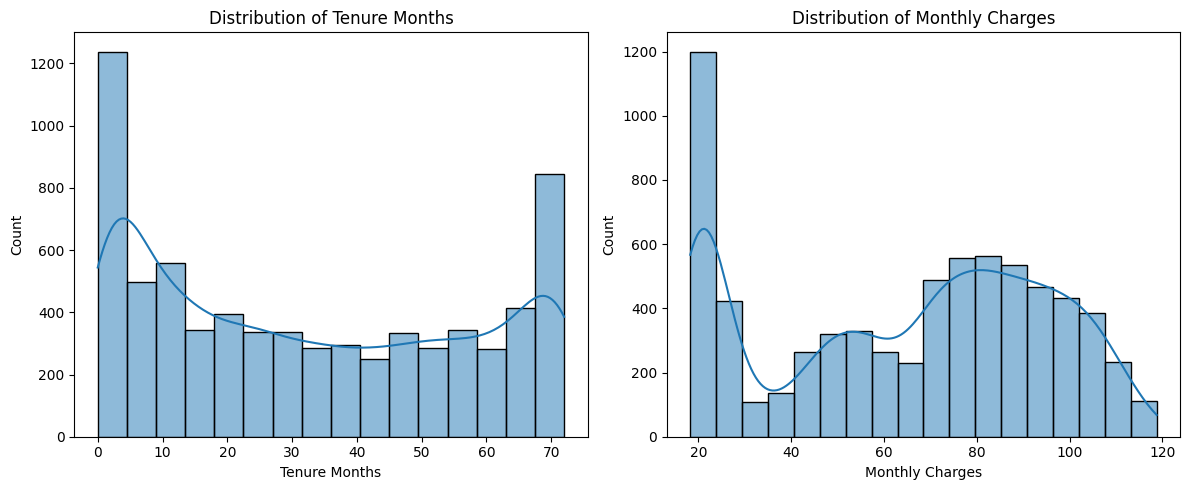

In [32]:
plt.figure(figsize=(12, 5))

numerical_cols = ["Tenure Months", "Monthly Charges"]

for i, col in enumerate(numerical_cols):
    plt.subplot(1, 2, i + 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

### Target Distribution

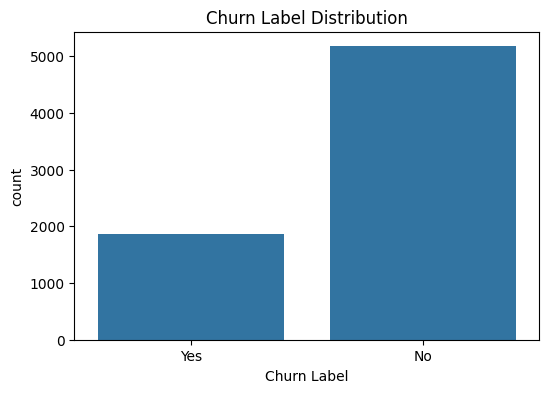

In [33]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn Label")

plt.title("Churn Label Distribution")
plt.show()

### Categorical Features Distribution

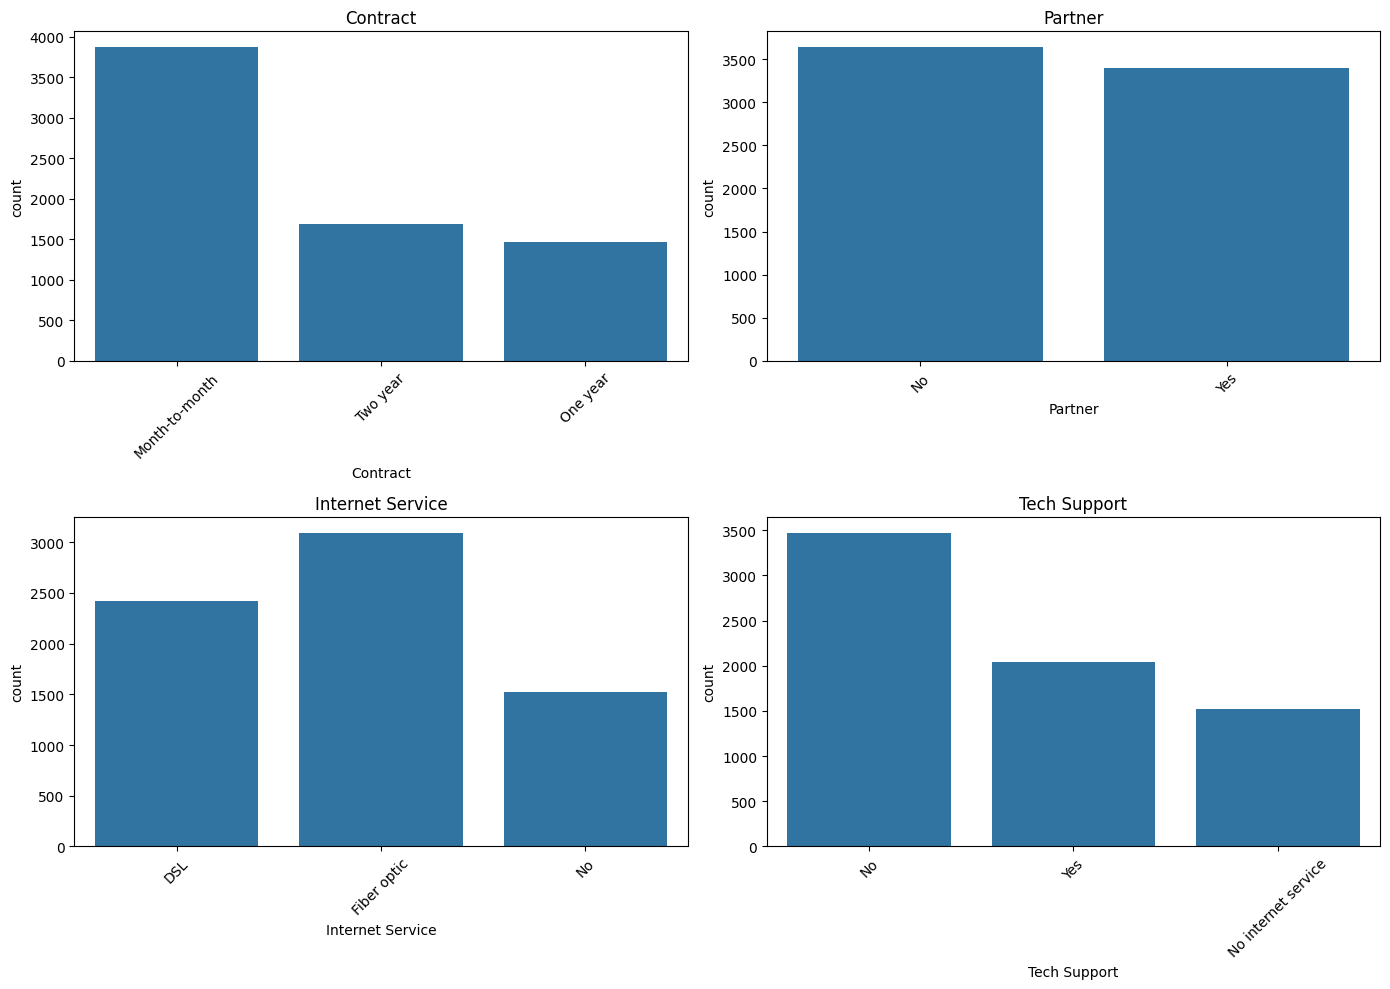

In [34]:
categorical_cols = [
    "Contract",
    "Partner",
    "Internet Service",
    "Tech Support"
]

plt.figure(figsize=(14,10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

# Churn vs Feature Analysis

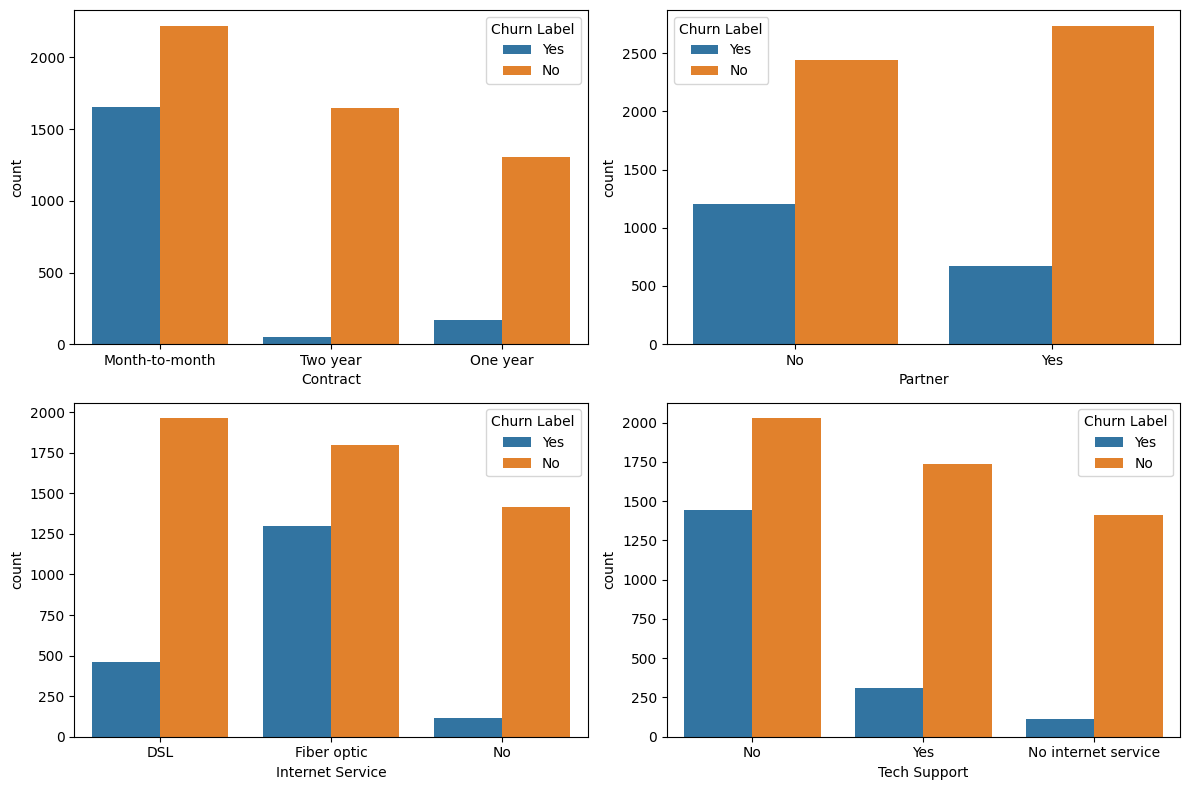

In [35]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.countplot(data=df, x="Contract", hue="Churn Label")

plt.subplot(2,2,2)
sns.countplot(data=df, x="Partner", hue="Churn Label")

plt.subplot(2,2,3)
sns.countplot(data=df, x="Internet Service", hue="Churn Label")

plt.subplot(2,2,4)
sns.countplot(data=df, x="Tech Support", hue="Churn Label")

plt.tight_layout()
plt.show()

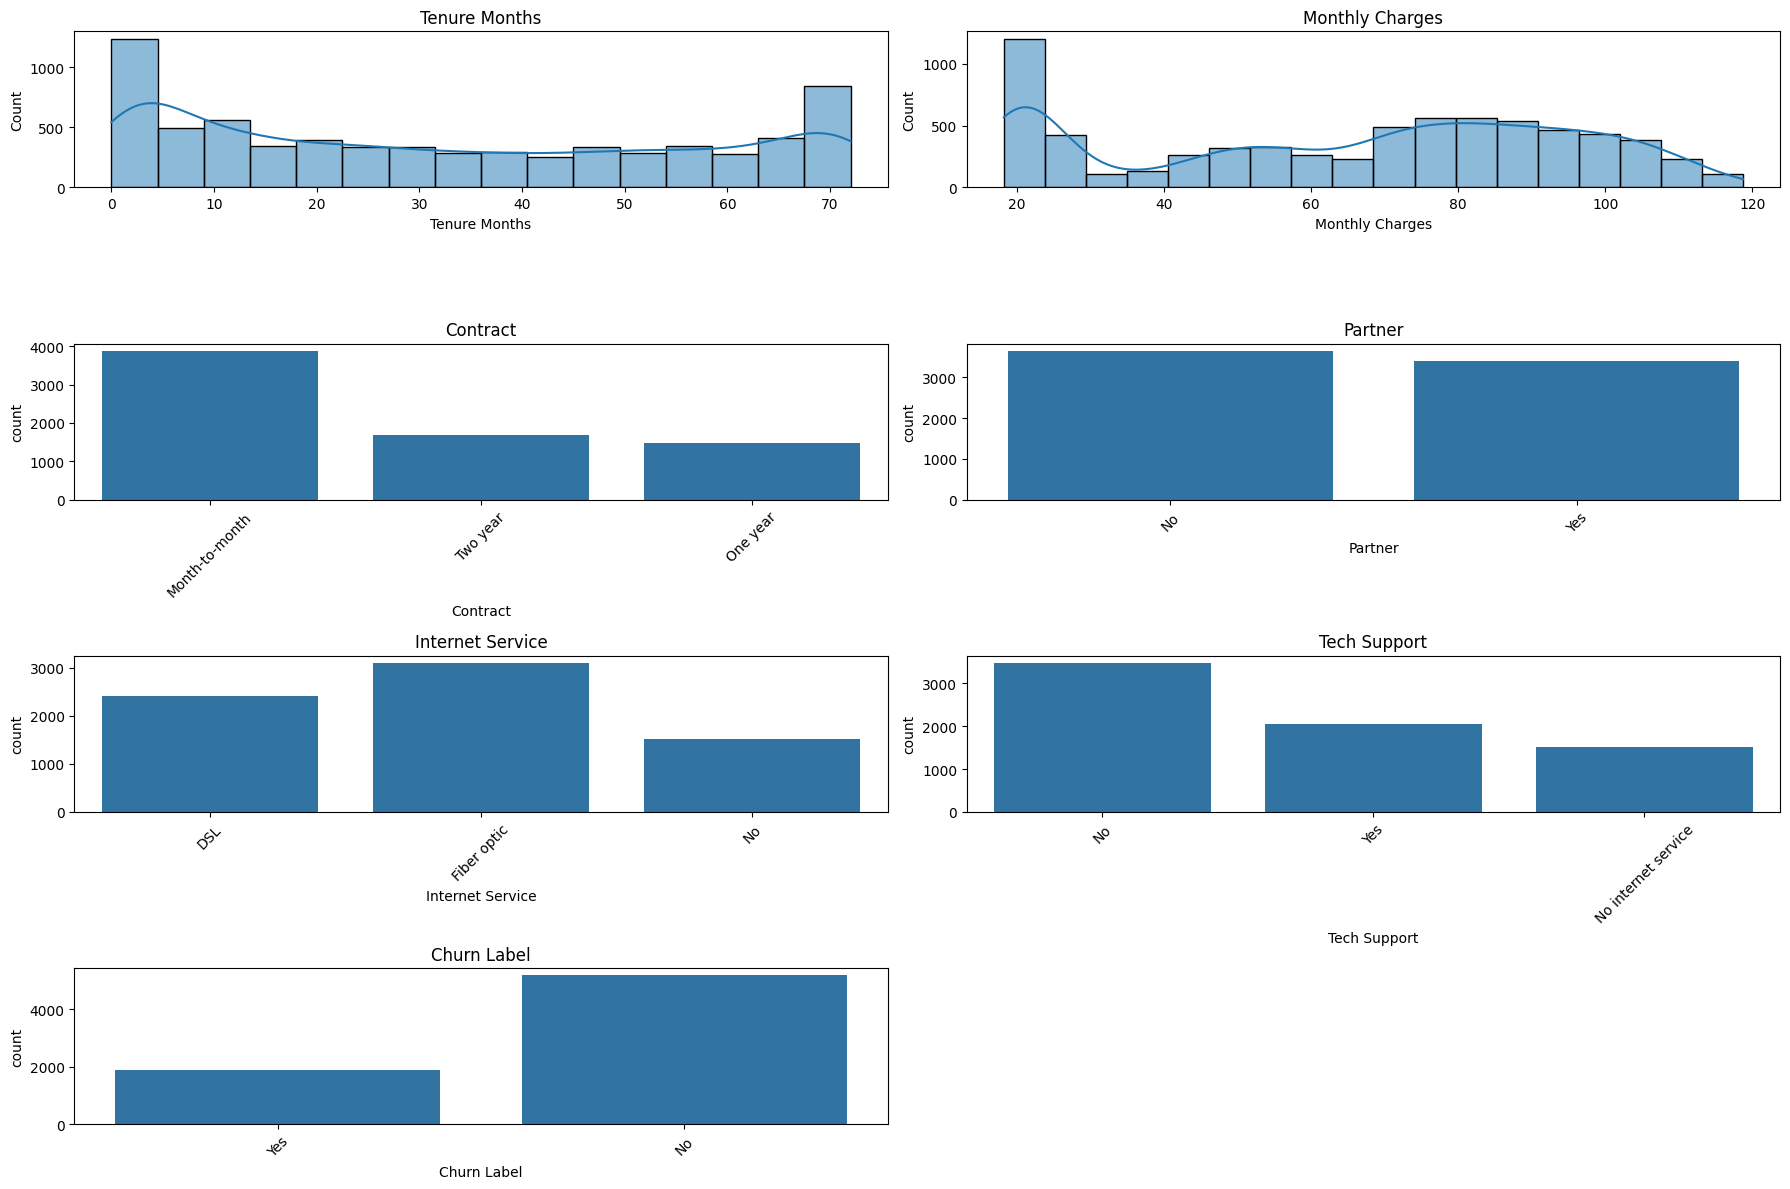

In [36]:
all_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Contract",
    "Partner",
    "Internet Service",
    "Tech Support",
    "Churn Label"
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(all_cols):

    plt.subplot(4, 2, i + 1)

    if df[col].dtype == "object":
        sns.countplot(data=df, x=col)
        plt.xticks(rotation=45)

    else:
        sns.histplot(data=df, x=col, kde=True)

    plt.title(col)

plt.tight_layout()
plt.show()

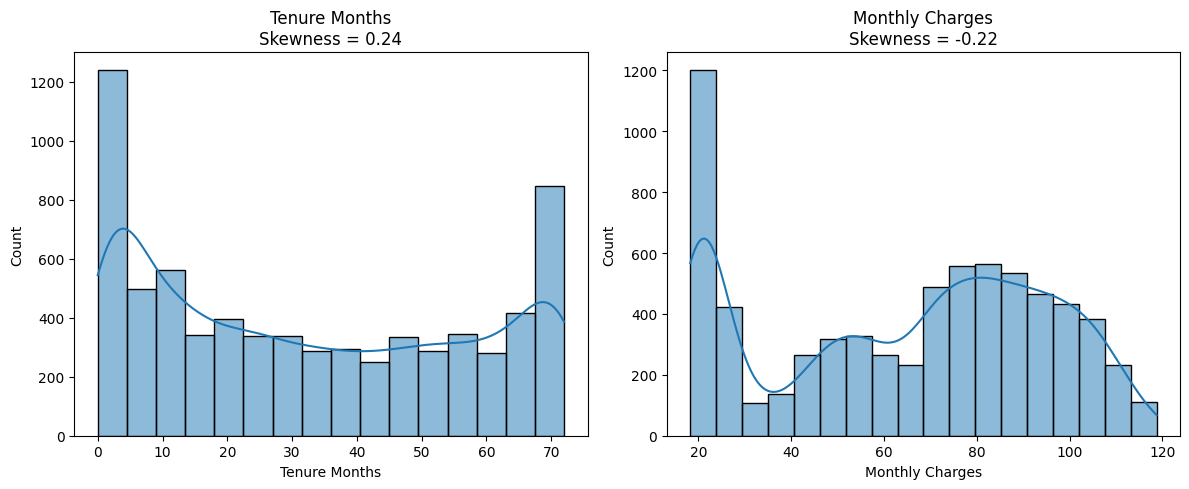

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_features = [
    "Tenure Months",
    "Monthly Charges"
]

plt.figure(figsize=(12,5))

for i, col in enumerate(continuous_features):
    plt.subplot(1,2,i+1)

    sns.histplot(df[col], kde=True)

    skew = round(df[col].skew(), 2)

    plt.title(f"{col}\nSkewness = {skew}")

plt.tight_layout()
plt.show()

## Apply Power Transformer to Check if it can reduces the outliers

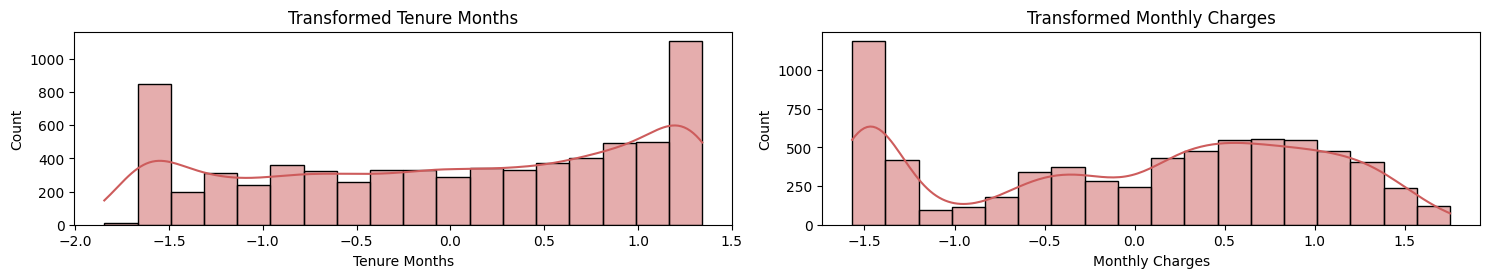

In [39]:
from sklearn.preprocessing import PowerTransformer

# 1. PowerTransformer initialize karein
pt = PowerTransformer(method='yeo-johnson')

# 2. Skewed features jo aap transform karna chahte hain
# Maine aapke continuous_features list ka use kiya hai
transform_features = continuous_features 

# 3. Fit aur Transform karein
# X_copy mein transform hone ke baad values store hongi
X_transformed = pt.fit_transform(df[transform_features])
X_transformed_df = pd.DataFrame(X_transformed, columns=transform_features)

# 4. Visualization (Transform hone ke baad)
plt.figure(figsize=(15, 10))
for i, col in enumerate(transform_features):
    plt.subplot(4, 2, i+1) # 8 features ke liye 4 rows x 2 cols
    sns.histplot(x=X_transformed_df[col], kde=True, color='indianred')
    plt.title(f'Transformed {col}')
    plt.tight_layout()

plt.show()

In [40]:
for feature in cat_features:
    print(feature,':', df[feature].nunique())

Partner : 2
Internet Service : 3
Tech Support : 3
Contract : 3
Churn Label : 2


## Feature Encoding and Scaling

### Power Transformer

Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

Selecting number features for preprocessing

In [42]:
num_features = list(X.select_dtypes(exclude="object").columns)

In [43]:
num_features

['Tenure Months', 'Monthly Charges']

### Preprocessing using Column Transformer

In [45]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = [
    "Tenure Months",
    "Monthly Charges"
]

categorical_features = [
    "Contract",
    "Partner",
    "Internet Service",
    "Tech Support"
]

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [46]:
X = preprocessor.fit_transform(X)

In [47]:
X

array([[-1.23672422, -0.36266036,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-1.23672422,  0.19736523,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.99240204,  1.1595457 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.61370124,  1.27753328,  1.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.87024095, -1.1686319 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.36937906,  1.35896134,  0.        , ...,  0.        ,
         0.        ,  1.        ]], shape=(7043, 9))

# Classification

### Model training se pahle Imblanced problem ko solve karenge so see in below

In [50]:
y = df['Churn Label'].map({'Yes': 1, 'No': 0})

In [51]:
from imblearn.combine import SMOTETomek, SMOTEENN

# Resampling the minority class. The strategy can be changed as required.
smt = SMOTEENN(random_state=42,sampling_strategy='minority' )
# Fit the model to generate the data.
X_res, y_res = smt.fit_resample(X, y)

# Train Test Split

The train-test split procedure is used to estimate the performance of machine learning algorithms when they are used to make predictions on data not used to train the model.

It is a fast and easy procedure to perform, the results of which allow you to compare the performance of machine learning algorithms.

In [52]:
from sklearn.model_selection import  train_test_split
# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((4806, 9), (1202, 9))

In [53]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [54]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted) # Calculate Accuracy
    f1 = f1_score(true, predicted) # Calculate F1-score
    precision = precision_score(true, predicted) # Calculate Precision
    recall = recall_score(true, predicted)  # Calculate Recall
    roc_auc = roc_auc_score(true, predicted) #Calculate Roc
    return acc, f1 , precision, recall, roc_auc

In [55]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(), 
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [56]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    
    models_list = []
    accuracy_list = []
    auc= []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Training set performance
        model_train_accuracy, model_train_f1,model_train_precision,\
        model_train_recall,model_train_rocauc_score=evaluate_clf(y_train ,y_train_pred)


        # Test set performance
        model_test_accuracy,model_test_f1,model_test_precision,\
        model_test_recall,model_test_rocauc_score=evaluate_clf(y_test, y_test_pred)

        print(list(models.keys())[i])
        models_list.append(list(models.keys())[i])

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(model_train_accuracy))
        print('- F1 score: {:.4f}'.format(model_train_f1)) 
        print('- Precision: {:.4f}'.format(model_train_precision))
        print('- Recall: {:.4f}'.format(model_train_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

        print('----------------------------------')

        print('Model performance for Test set')
        print('- Accuracy: {:.4f}'.format(model_test_accuracy))
        accuracy_list.append(model_test_accuracy)
        print('- F1 score: {:.4f}'.format(model_test_f1))
        print('- Precision: {:.4f}'.format(model_test_precision))
        print('- Recall: {:.4f}'.format(model_test_recall))
        print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
        auc.append(model_test_rocauc_score)
        print('='*35)
        print('\n')
        
    report=pd.DataFrame(list(zip(models_list, accuracy_list)), columns=['Model Name', 'Accuracy']).sort_values(by=['Accuracy'], ascending=False)
        
    return report

In [57]:
base_model_report =evaluate_models(X=X_res, y=y_res, models=models)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9742
- F1 score: 0.9732
- Precision: 0.9740
- Recall: 0.9724
- Roc Auc Score: 0.9741


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9576
- F1 score: 0.9555
- Precision: 0.9664
- Recall: 0.9447
- Roc Auc Score: 0.9571


Gradient Boosting
Model performance for Training set
- Accuracy: 0.9363
- F1 score: 0.9376
- Precision: 0.9315
- Recall: 0.9438
- Roc Auc Score: 0.9362
----------------------------------
Model performance for Test set
- Accuracy: 0.9293
- F1 score: 0.9267
- Precision: 0.9259
- Recall: 0.9275
- Roc Auc Score: 0.9292


Logistic Regression
Model performance for Training 

# Results of All Models

In [58]:
base_model_report

,Model Name,Accuracy
0,Random Forest,0.974210
5,XGBClassifier,0.965890
4,K-Neighbors Classifier,0.959235
6,CatBoosting Classifier,0.957571
1,Decision Tree,0.957571
2,Gradient Boosting,0.929285
8,AdaBoost Classifier,0.918469
7,Support Vector Classifier,0.915141
3,Logistic Regression,0.900998


In [60]:
# Initialize Hyperparameter Space for Models

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ['sqrt', 'log2']
}

xgboost_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ['uniform', 'distance'],
    "algorithm": ['auto', 'ball_tree', 'kd_tree', 'brute'],
    "p": [1, 2]
}

catboost_params = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "iterations": [100, 200, 300],
    "l2_leaf_reg": [1, 3, 5, 7]
}

gradient_boosting_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.7, 0.8, 1.0]
}

In [61]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier

# Models list for Hyperparameter tuning
randomcv_models = [
    ("Random Forest", RandomForestClassifier(), rf_params),
    ("XGBoost", XGBClassifier(eval_metric='logloss'), xgboost_params),
    ("KNN", KNeighborsClassifier(), knn_params),
    ("CatBoost", CatBoostClassifier(verbose=0), catboost_params),
    ("Gradient Boosting", GradientBoostingClassifier(), gradient_boosting_params)
]

In [65]:
randomcv_models = [
    ("Random Forest", RandomForestClassifier(), rf_params),
    ("XGBoost", XGBClassifier(eval_metric='logloss'), xgboost_params),
    ("KNN", KNeighborsClassifier(), knn_params),
    ("CatBoost", CatBoostClassifier(verbose=0), catboost_params),
    ("Gradient Boosting", GradientBoostingClassifier(), gradient_boosting_params)
]

best_parameters = tune_models(randomcv_models, X_res, y_res)

print("\n--- Best Parameters Found ---")
for model, params in best_parameters.items():
    print(f"{model}: {params}")


🔹 Training Started for: Random Forest
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✅ Training Completed for: Random Forest

🔹 Training Started for: XGBoost
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✅ Training Completed for: XGBoost

🔹 Training Started for: KNN
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✅ Training Completed for: KNN

🔹 Training Started for: CatBoost
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✅ Training Completed for: CatBoost

🔹 Training Started for: Gradient Boosting
Fitting 3 folds for each of 50 candidates, totalling 150 fits
✅ Training Completed for: Gradient Boosting

--- Best Parameters Found ---
Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
XGBoost: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
KNN: {'weights': 'distance', 'p': 2,

# Retraining the Model with best Parameters

In [69]:
from sklearn.metrics import roc_auc_score, roc_curve

best_models = {
    "Random Forest Classifier": RandomForestClassifier(
        **best_parameters["Random Forest"]
    ),

    "KNeighborsClassifier": KNeighborsClassifier(
        **best_parameters["KNN"]
    ),

    "XGBClassifier": XGBClassifier(
        **best_parameters["XGBoost"],
        n_jobs=-1,
        eval_metric='logloss'
    ),

    "CatBoostClassifier": CatBoostClassifier(
        **best_parameters["CatBoost"],
        verbose=0
    ),

    "Gradient Boosting Classifier": GradientBoostingClassifier(
        **best_parameters["Gradient Boosting"]
    )
}

tuned_report = evaluate_models(
    X=X_res,
    y=y_res,
    models=best_models
)

Random Forest Classifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9767
- F1 score: 0.9759
- Precision: 0.9726
- Recall: 0.9793
- Roc Auc Score: 0.9768


KNeighborsClassifier
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9908
- F1 score: 0.9905
- Precision: 0.9897
- Recall: 0.9914
- Roc Auc Score: 0.9909


XGBClassifier
Model performance for Training set
- Accuracy: 0.9990
- F1 score: 0.9990
- Precision: 0.9980
- Recall: 1.0000
- Roc Auc Score: 0.9989
----------------------------------
Model performance for Test set
- Accuracy: 0.9725
- F1 score: 0.9716
- Precision: 0.9675
- Recall: 0.9758
- Roc Auc Score: 0.9727


CatBoostClassifier
Model performance 

In [70]:
tuned_report

,Model Name,Accuracy
1,KNeighborsClassifier,0.990849
3,CatBoostClassifier,0.980033
0,Random Forest Classifier,0.976705
2,XGBClassifier,0.972546
4,Gradient Boosting Classifier,0.967554


In [71]:
from sklearn.metrics import accuracy_score, classification_report

# Best Model (from tuning results)
best_model = KNeighborsClassifier(**best_parameters["KNN"])

# Train model
best_model.fit(X_train, y_train)

# Predictions
y_pred = best_model.predict(X_test)

# Evaluation
score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

# Results
print("FINAL MODEL: KNeighborsClassifier")
print("Accuracy Score value: {:.4f}".format(score))
print("\nClassification Report:\n", cr)

FINAL MODEL: KNeighborsClassifier
Accuracy Score value: 0.9908

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       623
           1       0.99      0.99      0.99       579

    accuracy                           0.99      1202
   macro avg       0.99      0.99      0.99      1202
weighted avg       0.99      0.99      0.99      1202



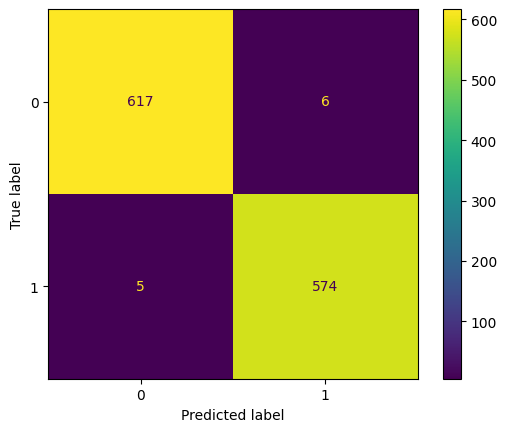

In [72]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)